In [1]:
# Read and print JSON or JSONL files from lab_subject directories.

from pathlib import Path
import json

root = Path(r"C:\Users\katly\Downloads\RAG-RecSys-data")

for subject_dir in sorted(root.glob("lab_subject_*")):
    for ext in ["json", "jsonl"]:
        file_path = subject_dir / f"exp_20260721T091553Z_7b92ec42_export.{ext}"

        if file_path.exists():
            print(f"Reading: {file_path}")

            if ext == "json":
                with file_path.open("r", encoding="utf-8") as f:
                    data = json.load(f)
            else:
                with file_path.open("r", encoding="utf-8") as f:
                    data = [json.loads(line) for line in f if line.strip()]

            print("Loaded:", type(data).__name__)
            print(data[:2] if isinstance(data, list) else data)

In [2]:
# Create a CSV file with participant-by-condition Credibility, Helpfulness, Convincingness, Relevance, and Neutrality scores 
# from post_condition_survey_submitted events in the Experiment directory.
# Add personality and behaviour survey scores to the participant-by-condition CSV.

from pathlib import Path
import json
import csv
from collections import defaultdict

root = Path("Experiment")

# Reuse the same aggregation logic as above, but now add survey-score columns.
scores = defaultdict(list)

for path in sorted(root.rglob("*_export.jsonl")):
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            rec = json.loads(line)
            if rec.get("event") != "post_condition_survey_submitted":
                continue

            data = rec.get("data", {})
            resp = data.get("responses", {})

            participant = rec.get("participant_id") or data.get("participant_id")
            condition = data.get("condition") or rec.get("condition") or "unknown"
            if not participant:
                continue

            def get(name):
                return resp.get(name)

            credibility = None
            llm_false = get("llm_false")
            llm_made_up = get("llm_made_up")
            if llm_false is not None and llm_made_up is not None:
                llm_false_inverse = 1 - llm_false
                llm_made_up_inverse = 1 - llm_made_up
                credibility = (llm_false_inverse + llm_made_up_inverse) / 2

            helpfulness = None
            llm_helpful = get("llm_helpful")
            llm_addressed = get("llm_addressed")
            llm_not_aid = get("llm_not_aid")
            if llm_helpful is not None and llm_addressed is not None and llm_not_aid is not None:
                llm_not_aid_inverse = 1 - llm_not_aid
                helpfulness = (llm_helpful + llm_addressed + llm_not_aid_inverse) / 3

            convincingness = None
            llm_skeptical = get("llm_skeptical")
            llm_convincing = get("llm_convincing")
            if llm_skeptical is not None and llm_convincing is not None:
                llm_skeptical_inverse = 1 - llm_skeptical
                convincingness = (llm_skeptical_inverse + llm_convincing) / 2

            relevance = None
            llm_not_useful = get("llm_not_useful")
            llm_suggestions = get("llm_suggestions")
            llm_relevant = get("llm_relevant")
            if llm_not_useful is not None and llm_suggestions is not None and llm_relevant is not None:
                llm_not_useful_inverse = 1 - llm_not_useful
                relevance = (llm_not_useful_inverse + llm_suggestions + llm_relevant) / 3

            neutrality = None
            if get("llm_neutral") is not None and get("llm_impartial") is not None:
                neutrality = (get("llm_neutral") + get("llm_impartial")) / 2

            # Personality and behaviour survey score fields
            personality_trust = get("personality_trust")
            personality_influence = get("personality_influence")
            personality_changed_mind = get("personality_changed_mind")
            personality_brands = get("personality_brands")
            personality_sponsored = get("personality_sponsored")
            behaviour_pushing = get("behaviour_pushing")
            behaviour_manipulate = get("behaviour_manipulate")

            scores[(participant, condition)].append(
                {
                    "credibility": credibility,
                    "helpfulness": helpfulness,
                    "convincingness": convincingness,
                    "relevance": relevance,
                    "neutrality": neutrality,
                    "personality_trust": personality_trust,
                    "personality_influence": personality_influence,
                    "personality_changed_mind": personality_changed_mind,
                    "personality_brands": personality_brands,
                    "personality_sponsored": personality_sponsored,
                    "behaviour_pushing": behaviour_pushing,
                    "behaviour_manipulate": behaviour_manipulate,
                }
            )

rows = []
for (participant, condition), entries in sorted(scores.items()):
    def avg(key):
        vals = [e[key] for e in entries if e[key] is not None]
        return sum(vals) / len(vals) if vals else None

    rows.append(
        {
            "participant_id": participant,
            "condition": condition,
            "credibility": avg("credibility"),
            "helpfulness": avg("helpfulness"),
            "convincingness": avg("convincingness"),
            "relevance": avg("relevance"),
            "neutrality": avg("neutrality"),
            "personality_trust": avg("personality_trust"),
            "personality_influence": avg("personality_influence"),
            "personality_changed_mind": avg("personality_changed_mind"),
            "personality_brands": avg("personality_brands"),
            "personality_sponsored": avg("personality_sponsored"),
            "behaviour_pushing": avg("behaviour_pushing"),
            "behaviour_manipulate": avg("behaviour_manipulate"),
        }
    )

out_path = Path("participant_condition_scores.csv")
with out_path.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=[
            "participant_id",
            "condition",
            "credibility",
            "helpfulness",
            "convincingness",
            "relevance",
            "neutrality",
            "personality_trust",
            "personality_influence",
            "personality_changed_mind",
            "personality_brands",
            "personality_sponsored",
            "behaviour_pushing",
            "behaviour_manipulate",
        ],
    )
    writer.writeheader()
    writer.writerows(rows)

print(f"Wrote {len(rows)} rows to {out_path}")

Wrote 90 rows to participant_condition_scores.csv


In [ ]:
# Shapiro-Wilk normality test for each score within each condition.
# H0: the sample comes from a normal distribution.
# Reject H0 (non-normal) when p < 0.05.

from pathlib import Path
import pandas as pd
from scipy import stats

csv_path = Path("participant_condition_scores.csv")
df = pd.read_csv(csv_path)

score_cols = [
    "credibility",
    "helpfulness",
    "convincingness",
    "relevance",
    "neutrality",
    "behaviour_pushing",
    "behaviour_manipulate",
]

rows = []
for condition, g in df.groupby("condition", sort=True):
    for col in score_cols:
        values = g[col].dropna().astype(float)
        n = len(values)
        if n < 3:
            stat = p = None
            normal = None
            note = "n < 3; Shapiro-Wilk not run"
        else:
            stat, p = stats.shapiro(values)
            normal = bool(p >= 0.05)
            note = "normal (fail to reject H0)" if normal else "non-normal (reject H0)"

        rows.append(
            {
                "condition": condition,
                "score": col,
                "n": n,
                "shapiro_W": None if stat is None else round(float(stat), 4),
                "shapiro_p": None if p is None else round(float(p), 4),
                "normal_at_0.05": normal,
                "interpretation": note,
            }
        )

shapiro_df = pd.DataFrame(rows)
out_path = Path("condition_shapiro_wilk.csv")
shapiro_df.to_csv(out_path, index=False)

print(f"Wrote {len(shapiro_df)} rows to {out_path}")
print()
print("Shapiro-Wilk by condition × score (p < 0.05 => reject normality):")
print(
    f"{'condition':<14} {'score':<22} {'n':>3} {'W':>7} {'p':>8}  interpretation"
)
for _, row in shapiro_df.iterrows():
    w = "" if row["shapiro_W"] is None else f"{row['shapiro_W']:.4f}"
    p = "" if row["shapiro_p"] is None else f"{row['shapiro_p']:.4f}"
    print(
        f"{row['condition']:<14} {row['score']:<22} {int(row['n']):>3} "
        f"{w:>7} {p:>8}  {row['interpretation']}"
    )

print()
violations = shapiro_df[shapiro_df["normal_at_0.05"] == False]
print(f"Non-normal cells (p < 0.05): {len(violations)} / {len(shapiro_df)}")
if not violations.empty:
    print(violations[["condition", "score", "n", "shapiro_W", "shapiro_p"]].to_string(index=False))


<Figure size 800x500 with 0 Axes>

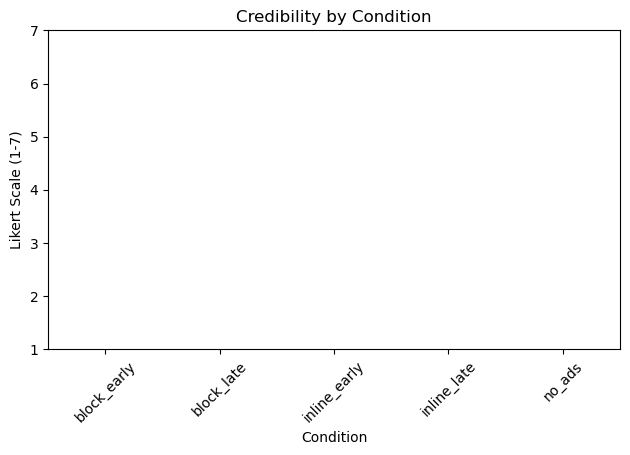

<Figure size 800x500 with 0 Axes>

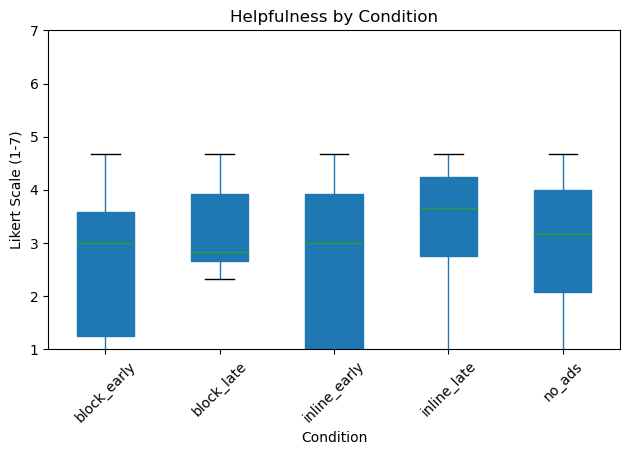

<Figure size 800x500 with 0 Axes>

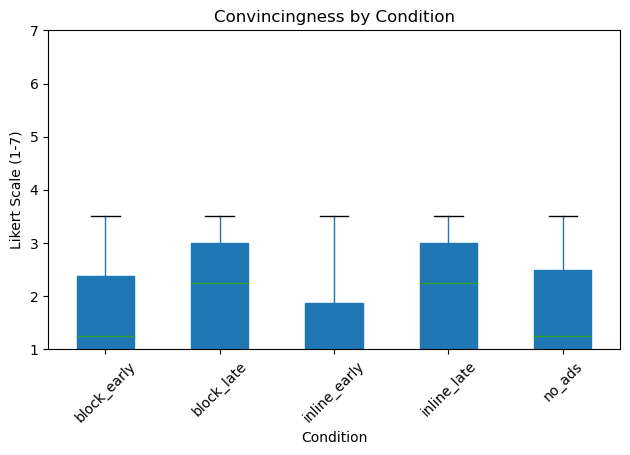

<Figure size 800x500 with 0 Axes>

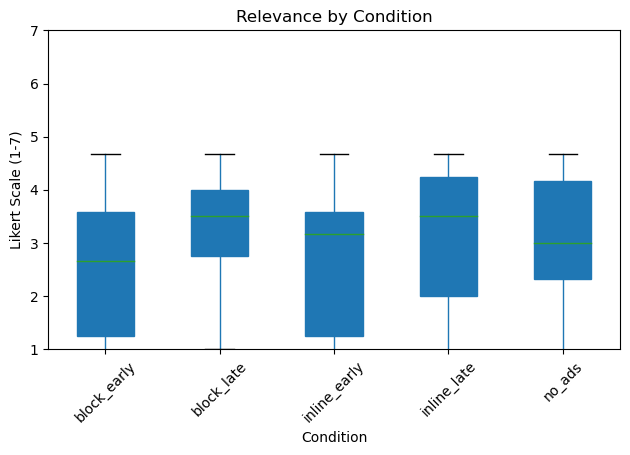

<Figure size 800x500 with 0 Axes>

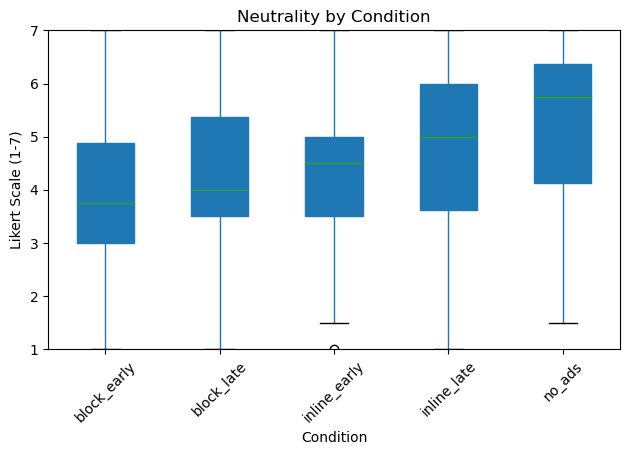

<Figure size 800x500 with 0 Axes>

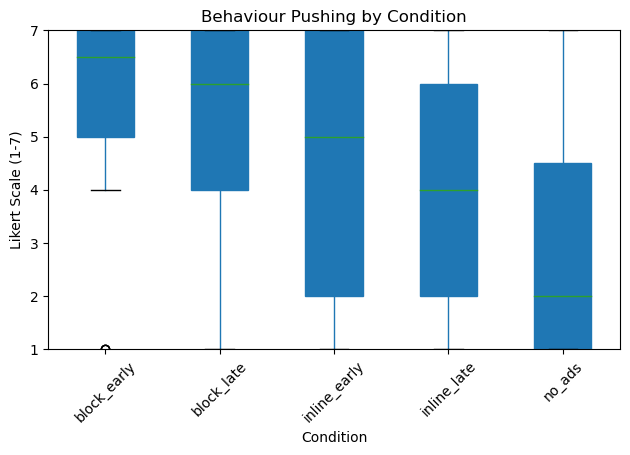

<Figure size 800x500 with 0 Axes>

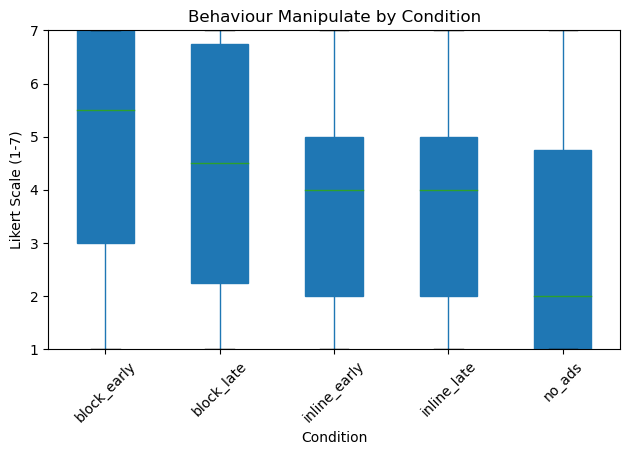

In [3]:
# Create boxplots for the composite and behaviour scores by condition using the exported CSV.

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

csv_path = Path("participant_condition_scores.csv")
df = pd.read_csv(csv_path)

# Keep only the columns requested for plotting
score_cols = [
    "credibility",
    "helpfulness",
    "convincingness",
    "relevance",
    "neutrality",
    "behaviour_pushing",
    "behaviour_manipulate",
]

# Scores that are true 1-7 Likert items (composites can fall outside that range)
likert_cols = {"behaviour_pushing", "behaviour_manipulate"}

# Ensure the condition order is consistent
condition_order = sorted(df["condition"].dropna().unique())
df["condition"] = pd.Categorical(df["condition"], categories=condition_order, ordered=True)

# Keep figure handles so the next cell can save them
boxplot_figures = {}

for col in score_cols:
    # pandas boxplot(by=...) creates its own figure; capture that figure (not a prior empty one)
    ax = df.boxplot(column=col, by="condition", grid=False, patch_artist=True, figsize=(8, 5))
    # When by= is used, ax may be an ndarray; use the current figure
    fig = plt.gcf()
    plt.title(f"{col.replace('_', ' ').title()} by Condition")
    plt.suptitle("")
    plt.xlabel("Condition")
    if col in likert_cols:
        plt.ylabel("Likert Scale (1-7)")
        plt.ylim(1, 7)
    else:
        plt.ylabel("Score")
        # composites (e.g. credibility) are not bounded to 1-7
        ymin = float(df[col].min())
        ymax = float(df[col].max())
        pad = max(0.5, 0.05 * (ymax - ymin if ymax > ymin else 1.0))
        plt.ylim(ymin - pad, ymax + pad)
    plt.xticks(rotation=45)
    plt.tight_layout()
    boxplot_figures[col] = fig
    plt.show()

print(f"Created {len(boxplot_figures)} boxplots: {', '.join(boxplot_figures)}")


In [ ]:
# Save the boxplots into boxplots_outputs/.
# Uses figures from the previous cell when available; otherwise recreates them from the CSV.

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

out_dir = Path("boxplots_outputs")
out_dir.mkdir(exist_ok=True)

score_cols = [
    "credibility",
    "helpfulness",
    "convincingness",
    "relevance",
    "neutrality",
    "behaviour_pushing",
    "behaviour_manipulate",
]
likert_cols = {"behaviour_pushing", "behaviour_manipulate"}


def _build_boxplot_figures(df: pd.DataFrame) -> dict:
    figures = {}
    condition_order = sorted(df["condition"].dropna().unique())
    plot_df = df.copy()
    plot_df["condition"] = pd.Categorical(
        plot_df["condition"], categories=condition_order, ordered=True
    )

    for col in score_cols:
        plot_df.boxplot(column=col, by="condition", grid=False, patch_artist=True, figsize=(8, 5))
        fig = plt.gcf()
        plt.title(f"{col.replace('_', ' ').title()} by Condition")
        plt.suptitle("")
        plt.xlabel("Condition")
        if col in likert_cols:
            plt.ylabel("Likert Scale (1-7)")
            plt.ylim(1, 7)
        else:
            plt.ylabel("Score")
            ymin = float(plot_df[col].min())
            ymax = float(plot_df[col].max())
            pad = max(0.5, 0.05 * (ymax - ymin if ymax > ymin else 1.0))
            plt.ylim(ymin - pad, ymax + pad)
        plt.xticks(rotation=45)
        plt.tight_layout()
        figures[col] = fig
    return figures


# Prefer figures from the create cell; rebuild if missing or already closed
need_rebuild = (
    "boxplot_figures" not in globals()
    or not boxplot_figures
    or any(not plt.fignum_exists(fig.number) for fig in boxplot_figures.values())
)

if need_rebuild:
    print("boxplot_figures missing/closed — recreating from participant_condition_scores.csv")
    df = pd.read_csv(Path("participant_condition_scores.csv"))
    boxplot_figures = _build_boxplot_figures(df)

for col, fig in boxplot_figures.items():
    out_path = out_dir / f"boxplot_{col}_by_condition.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Wrote {out_path}")
    plt.close(fig)

print(f"Saved {len(boxplot_figures)} boxplots to {out_dir}/")
